<a href="https://colab.research.google.com/github/nutangaonkar/CSL701-CE09-Machine-Learning-Lab/blob/main/Experiments/ML_EXP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Nutan Nandkishor Gaonkar
Roll No: CE09

In [35]:
#Aim: To implement a Simple Linear Regression model using Python and predict MPG from Horsepower using OLS.

In [36]:
#Task 1: Import Libraries.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
#Task 2: Load the Auto MPG Dataset

from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

df.head()

Saving auto-mpg.csv to auto-mpg (4).csv


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [38]:
# Task 3: Inspect and Clean Data

# Display basic information about the dataset
df.info()

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Remove rows with missing values
df = df.dropna()

# Display the cleaned dataset information
print("\nAfter cleaning:")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB

Missing values:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

After cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
--- 

In [39]:
# Task 4: Select Horsepower and MPG

X = df["horsepower"]
y = df["mpg"]

print("Horsepower:")
print(X.head())

print("\nMPG:")
print(y.head())

Horsepower:
0    130
1    165
2    150
3    150
4    140
Name: horsepower, dtype: object

MPG:
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


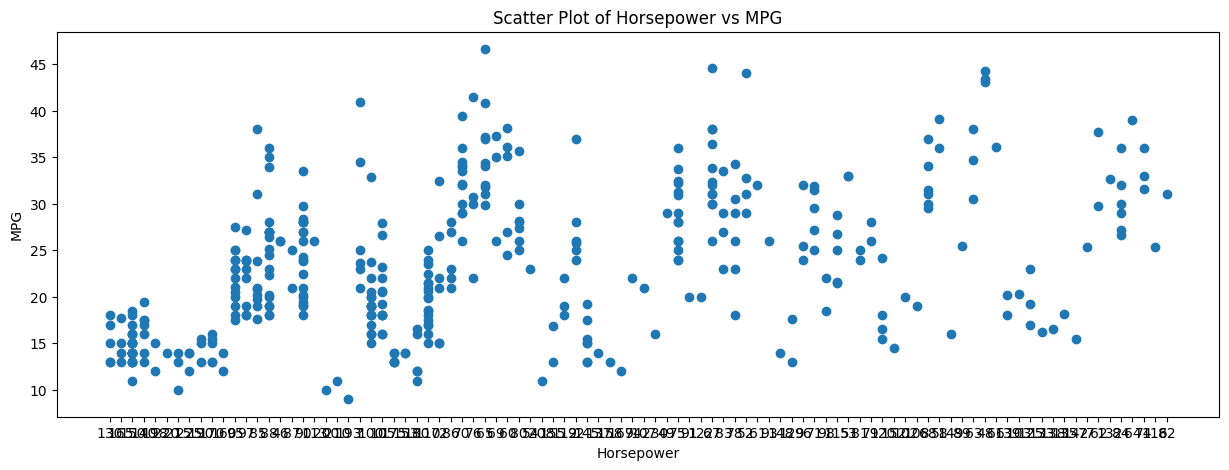

In [40]:
# Task 5: Plot Scatter Graph

plt.figure(figsize=(15, 5))

plt.scatter(X, y)

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Scatter Plot of Horsepower vs MPG")

plt.show()

In [41]:
# Task 6: Add Bias Term

X_bias = np.column_stack((np.ones(len(X)), X))

print(X_bias[:5])

[[1.0 '130']
 [1.0 '165']
 [1.0 '150']
 [1.0 '150']
 [1.0 '140']]


In [42]:
# Task 7: Compute Correlation

X = pd.to_numeric(X, errors="coerce")
correlation = X.corr(y)

print("Correlation between Horsepower and MPG:", correlation)

Correlation between Horsepower and MPG: -0.7784267838977756


In [46]:
# Task 8: Calculate OLS Weights


# Select and clean only the required columns
data = df[["horsepower", "mpg"]].copy()

# Convert values to numeric
data["horsepower"] = pd.to_numeric(data["horsepower"], errors="coerce")
data["mpg"] = pd.to_numeric(data["mpg"], errors="coerce")

# Remove missing values
data = data.dropna()

# Define X and y as numeric NumPy arrays
X = data["horsepower"].values.astype(float)
y = data["mpg"].values.astype(float)

# Add bias term
X_bias = np.column_stack((np.ones(len(X)), X))

# Calculate OLS weights using Normal Equation
weights = np.linalg.inv(X_bias.T @ X_bias) @ (X_bias.T @ y)

# Display weights
print("OLS Weights:", weights)

OLS Weights: [39.93586102 -0.15784473]


In [47]:
# Task 9: Predict Values

y_pred = X_bias @ weights

print("Predicted MPG values:")
print(y_pred[:5])

Predicted MPG values:
[19.41604569 13.89148002 16.25915102 16.25915102 17.83759835]


In [48]:
# Task 10: Compute Residuals

residuals = y - y_pred

print("First 5 residuals:")
print(residuals[:5])

First 5 residuals:
[-1.41604569  1.10851998  1.74084898 -0.25915102 -0.83759835]


In [49]:
# Task 11: Calculate SSE, MSE, and R²

# Calculate SSE
SSE = np.sum(residuals ** 2)

# Calculate MSE
MSE = np.mean(residuals ** 2)

# Calculate R²
R2 = 1 - (SSE / np.sum((y - np.mean(y)) ** 2))

# Display the results
print("SSE:", SSE)
print("MSE:", MSE)
print("R²:", R2)

SSE: 9385.915871932419
MSE: 23.943662938603108
R²: 0.6059482578894348


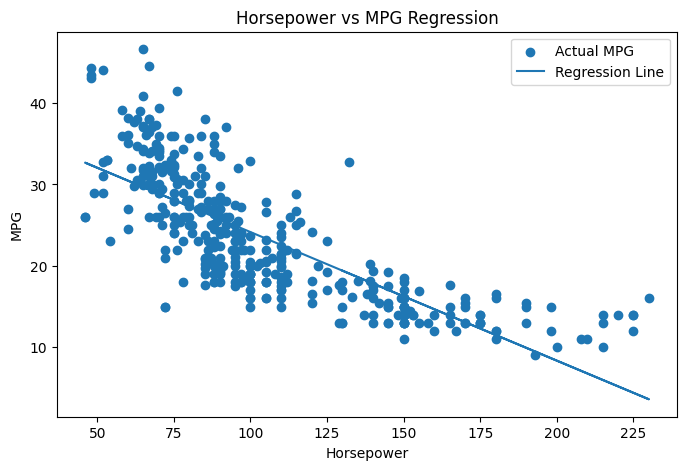

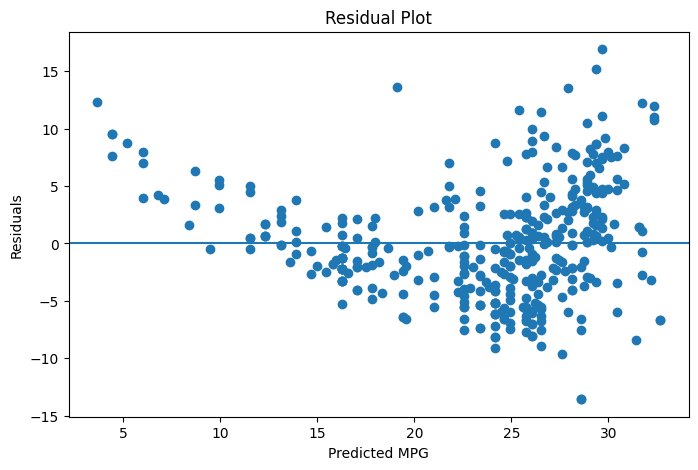

In [50]:
# Task 12: Plot Regression Graph

plt.figure(figsize=(8, 5))

# Scatter plot of actual values
plt.scatter(X, y, label="Actual MPG")

# Regression line
plt.plot(X, y_pred, label="Regression Line")

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs MPG Regression")
plt.legend()

plt.show()


# Residual Plot

plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [ ]:
## Task 13: Interpret Results

The Simple Linear Regression model successfully predicted MPG using Horsepower as the input variable.

The correlation coefficient is **-0.7784**, which indicates a strong negative relationship between Horsepower and MPG. This means that as Horsepower increases, MPG generally decreases.

The **SSE value is 9385.92**, which represents the total squared difference between the actual and predicted MPG values.

The **MSE value is 23.94**, which represents the average squared prediction error of the model.

The **R² value is 0.6059 or 60.59%**, which means that approximately 60.59% of the variation in MPG is explained by Horsepower.

The remaining variation in MPG may be influenced by other factors such as vehicle weight, number of cylinders, displacement, acceleration, and model year.

The regression and residual plots help visualize the relationship between Horsepower and MPG and show the prediction errors of the model.


Conclusion
The experiment successfully implemented Simple Linear Regression using OLS. Horsepower showed a negative relationship with MPG, and evaluation metrics demonstrated reasonable predictive performance.
